# 06 — Tutorial 1: Water Molecular Dynamics Simulation in LAMMPS

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module%202%20-%20Molecular%20dynamics/notebooks/06_tutorial_water_lammps.ipynb)

## 🎯 Learning Objectives

- SPC/E rigid water model and its parameters
- Structure of LAMMPS input scripts and data files
- LAMMPS input files for energy minimization, NVT and NPT runs
- O–O radial distribution function g(r)
- Self-diffusion coefficients of water from MSD

## 1. The SPC/E Water Model

The **SPC/E** (Extended Simple Point Charge) model (Berendsen *et al.* 1987) is one of the most widely used rigid water models for classical MD simulations.

### 1.1 Geometry

| Parameter | Value |
|-----------|-------|
| O–H bond length | 1.0 Å |
| H–O–H angle | 109.47° |

### 1.2 Non-bonded Parameters

Partial charges (self-polarization correction applied):
$$q_O = -0.8476\,e, \quad q_H = +0.4238\,e$$

Lennard-Jones parameters (oxygen only; hydrogen has no LJ):
$$\varepsilon_{OO} = 0.6502\,\text{kJ/mol}, \quad \sigma_{OO} = 3.166\,\text{Å}$$

### 1.3 Interaction Energy

$$U = \sum_{i<j} \left[ 4\varepsilon_{OO}\left(\left(\frac{\sigma_{OO}}{r_{OO}}\right)^{12} - \left(\frac{\sigma_{OO}}{r_{OO}}\right)^{6}\right) + \frac{1}{4\pi\varepsilon_0}\sum_{\alpha,\beta}\frac{q_\alpha q_\beta}{r_{\alpha\beta}} \right]$$

The molecule is kept **rigid** using the SHAKE/SETTLE algorithm — no bond-stretching or angle-bending terms are needed.

### 1.4 Performance of SPC/E

| Property | SPC/E | Experiment |
|----------|-------|------------|
| Density (g/cm³) | 0.997 | 0.997 |
| D (10⁻⁹ m²/s) | 2.4 | 2.3 |
| ΔH_vap (kJ/mol) | 44.0 | 44.0 |
| T_melt (K) | ~215 | 273 |

> **Note:** SPC/E underestimates the melting point but gives excellent liquid-state thermodynamics near 300 K.

## More about water models and theory: 
https://vitroid.github.io/water-science/water/water_models.html 

#### Intall with pip or conda, these important packages, MDanalysis and tidynamics 

In [1]:
# =============================================================================
# Ch121a: Molecular Dynamics — Notebook 06: Water MD Tutorial (LAMMPS)
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist
import os

matplotlib_params = {'figure.dpi': 120, 'font.size': 11,
                     'axes.labelsize': 12, 'legend.fontsize': 10}
plt.rcParams.update(matplotlib_params)

print('Packages loaded successfully.')

Packages loaded successfully.


## 2. Building a Water Box

We generate a simple-cubic lattice of water molecules. Each molecule is oriented with the oxygen at the lattice point and the two hydrogens placed according to the SPC/E geometry.

In [2]:
def build_water_box(n_side=6, density_g_cm3=0.997):
    """
    Build a cubic water box with n_side^3 molecules on a simple-cubic lattice.
    Returns positions (Angstrom), atom types, charges, and box length.
    """
    # SPC/E geometry
    rOH = 1.0          # Angstrom
    angle_HOH = np.deg2rad(109.47)
    
    # Water molecular mass
    mw_water = 18.015  # g/mol
    N_A = 6.022e23
    
    n_mol = n_side**3
    
    # Box length from density
    mass_g = n_mol * mw_water / N_A
    vol_cm3 = mass_g / density_g_cm3
    L_cm = vol_cm3**(1/3)
    L_ang = L_cm * 1e8  # convert cm to Angstrom
    
    spacing = L_ang / n_side
    
    positions = []  # (atom_id, mol_id, type, x, y, z)
    atom_id = 0
    mol_id = 0
    
    # H positions relative to O, in the xz plane
    half_ang = angle_HOH / 2
    H1_rel = np.array([ rOH * np.sin(half_ang), 0.0,  rOH * np.cos(half_ang)])
    H2_rel = np.array([-rOH * np.sin(half_ang), 0.0,  rOH * np.cos(half_ang)])
    
    for ix in range(n_side):
        for iy in range(n_side):
            for iz in range(n_side):
                mol_id += 1
                O_pos = np.array([ix, iy, iz]) * spacing + 0.5 * spacing
                
                # Add small random perturbation to avoid perfect lattice artifacts
                np.random.seed(mol_id)
                perturb = (np.random.rand(3) - 0.5) * 0.1
                O_pos += perturb
                
                H1_pos = O_pos + H1_rel
                H2_pos = O_pos + H2_rel
                
                atom_id += 1
                positions.append((atom_id, mol_id, 1, *O_pos))   # O: type 1
                atom_id += 1
                positions.append((atom_id, mol_id, 2, *H1_pos))  # H: type 2
                atom_id += 1
                positions.append((atom_id, mol_id, 2, *H2_pos))  # H: type 2
    
    return positions, n_mol, L_ang

positions, n_mol, L_ang = build_water_box(n_side=6)
n_atoms = len(positions)
print(f'Water box: {n_mol} molecules, {n_atoms} atoms')
print(f'Box length: {L_ang:.4f} Å  ({L_ang/10:.4f} nm)')
print(f'Expected density: ~0.997 g/cm³')

Water box: 216 molecules, 648 atoms
Box length: 18.6445 Å  (1.8644 nm)
Expected density: ~0.997 g/cm³


## 3. Writing the LAMMPS Data File

LAMMPS reads molecular topology from a **data file** containing masses, atom coordinates, bonds, and angles.

In [4]:
def write_lammps_data(filename, positions, n_mol, L_ang):
    """Write a LAMMPS data file for the SPC/E water box."""
    n_atoms = len(positions)
    n_bonds = n_mol * 2   # 2 O-H bonds per molecule
    n_angles = n_mol * 1  # 1 H-O-H angle per molecule
    
    # SPC/E charges
    q_O = -0.8476
    q_H =  0.4238
    
    lines = []
    lines.append('LAMMPS data file — SPC/E water box\n')
    lines.append(f'{n_atoms} atoms')
    lines.append(f'{n_bonds} bonds')
    lines.append(f'{n_angles} angles')
    lines.append('0 dihedrals')
    lines.append('0 impropers\n')
    lines.append('2 atom types')
    lines.append('1 bond types')
    lines.append('1 angle types\n')
    lines.append(f'0.0 {L_ang:.6f} xlo xhi')
    lines.append(f'0.0 {L_ang:.6f} ylo yhi')
    lines.append(f'0.0 {L_ang:.6f} zlo zhi\n')
    lines.append('Masses\n')
    lines.append('1 15.9994  # O')
    lines.append('2  1.0080  # H\n')
    lines.append('Atoms  # full\n')
    for p in positions:
        aid, mol, atype, x, y, z = p
        q = q_O if atype == 1 else q_H
        lines.append(f'{aid} {mol} {atype} {q:.4f} {x:.6f} {y:.6f} {z:.6f}')
    lines.append('')
    lines.append('Bonds\n')
    bond_id = 0
    for m in range(n_mol):
        base = m * 3  # 0-indexed
        O_id  = base + 1
        H1_id = base + 2
        H2_id = base + 3
        bond_id += 1; lines.append(f'{bond_id} 1 {O_id} {H1_id}')
        bond_id += 1; lines.append(f'{bond_id} 1 {O_id} {H2_id}')
    lines.append('')
    lines.append('Angles\n')
    for m in range(n_mol):
        base = m * 3
        O_id  = base + 1
        H1_id = base + 2
        H2_id = base + 3
        lines.append(f'{m+1} 1 {H1_id} {O_id} {H2_id}')
    
    content = '\n'.join(lines)
    with open(filename, 'w') as f:
        f.write(content)
    print(f'Wrote {filename} ({len(lines)} lines)')
    return content

# Write to /tmp for demonstration
data_content = write_lammps_data('../tmp/water.data', positions, n_mol, L_ang)
# Preview first 30 lines
for line in data_content.split('\n')[:30]:
    print(line)

Wrote ../tmp/water.data (1316 lines)
LAMMPS data file — SPC/E water box

648 atoms
432 bonds
216 angles
0 dihedrals
0 impropers

2 atom types
1 bond types
1 angle types

0.0 18.644498 xlo xhi
0.0 18.644498 ylo yhi
0.0 18.644498 zlo zhi

Masses

1 15.9994  # O
2  1.0080  # H

Atoms  # full

1 1 1 -0.8476 1.545410 1.575741 1.503720
2 1 2 0.4238 2.361901 1.575741 2.081079
3 1 2 0.4238 0.728920 1.575741 2.081079
4 2 1 -0.8476 1.547308 1.506301 4.666091
5 2 2 0.4238 2.363798 1.506301 5.243450
6 2 2 0.4238 0.730817 1.506301 5.243450
7 3 1 -0.8476 1.558788 1.574523 7.747631


## 4. LAMMPS Input Scripts

A LAMMPS simulation is controlled by an **input script**. We need three scripts:
1. Energy minimization (in [../tmp/in.minimize](../tmp/in.minimize)
2. NVT equilibration  
3. NPT production run

### Key LAMMPS Commands

| Command | Purpose |
|---------|--------|
| `units real` | Energy=kcal/mol, length=Å, time=fs |
| `atom_style full` | Supports charges and molecule IDs |
| `pair_style lj/cut/coul/long` | LJ + long-range Coulomb |
| `kspace_style pppm` | Particle-Particle Particle-Mesh Ewald |
| `fix shake` | Rigid bonds/angles (for SPC/E) |
| `fix nvt` | Nosé-Hoover thermostat |
| `fix npt` | Nosé-Hoover thermostat + barostat |
| `thermo` | Print thermodynamic info every N steps |
| `dump` | Write trajectory to file |

In [1]:
lammps_minimize = """
# ============================================================
# LAMMPS Input: SPC/E Water — Energy Minimization
# ============================================================
units           real
atom_style      full
boundary        p p p

read_data       water.data

# --- Force field ---
pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166   # O-O: eps(kcal/mol), sigma(Ang)
pair_coeff      1 2  0.0     0.0     # O-H: no LJ
pair_coeff      2 2  0.0     0.0     # H-H: no LJ

bond_style      harmonic
bond_coeff      1  1000.0 1.0        # stiff spring, r0=1.0 Ang

angle_style     harmonic
angle_coeff     1  1000.0 109.47     # stiff spring, theta0=109.47 deg

kspace_style    pppm 1.0e-4

# --- Constraints (rigid SPC/E bonds and angles) ---
fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

# --- Neighbor list ---
neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Minimization ---
minimize        1.0e-4 1.0e-6 1000 10000

write_data      water_min.data
"""

with open('../tmp/in.minimize', 'w') as f:
    f.write(lammps_minimize)
print('Energy minimization input script:')
print(lammps_minimize)

Energy minimization input script:

# ============================================================
# LAMMPS Input: SPC/E Water — Energy Minimization
# ============================================================
units           real
atom_style      full
boundary        p p p

read_data       water.data

# --- Force field ---
pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166   # O-O: eps(kcal/mol), sigma(Ang)
pair_coeff      1 2  0.0     0.0     # O-H: no LJ
pair_coeff      2 2  0.0     0.0     # H-H: no LJ

bond_style      harmonic
bond_coeff      1  1000.0 1.0        # stiff spring, r0=1.0 Ang

angle_style     harmonic
angle_coeff     1  1000.0 109.47     # stiff spring, theta0=109.47 deg

kspace_style    pppm 1.0e-4

# --- Constraints (rigid SPC/E bonds and angles) ---
fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

# --- Neighbor list ---
neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Minimization ---
minimize        1.0e

In [5]:
lammps_nvt = """
# ============================================================
# LAMMPS Input: SPC/E Water — NVT Equilibration (300 K, 100 ps)
# ============================================================
units           real
atom_style      full
boundary        p p p

read_data       water_min.data

pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166
pair_coeff      1 2  0.0 0.0
pair_coeff      2 2  0.0 0.0

bond_style      harmonic
bond_coeff      1  1000.0 1.0
angle_style     harmonic
angle_coeff     1  1000.0 109.47

kspace_style    pppm 1.0e-4

fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Velocity initialization ---
velocity        all create 300.0 12345 dist gaussian

# --- Nosé-Hoover thermostat: NVT ---
fix             nvt_water all nvt temp 300.0 300.0 100.0

# --- Timestep and run ---
timestep        1.0         # 2 fs is alo safe with SHAKE

thermo          100
thermo_style    custom step temp press density etotal ke pe

dump            1 all atom 500 nvt_traj.lammpstrj

run             50000       # 50 ps

write_data      water_nvt.data
write_restart   water_nvt.restart
"""

with open('../tmp/in.nvt', 'w') as f:
    f.write(lammps_nvt)
print('NVT equilibration input script:')
print(lammps_nvt)

NVT equilibration input script:

# ============================================================
# LAMMPS Input: SPC/E Water — NVT Equilibration (300 K, 100 ps)
# ============================================================
units           real
atom_style      full
boundary        p p p

read_data       water_min.data

pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166
pair_coeff      1 2  0.0 0.0
pair_coeff      2 2  0.0 0.0

bond_style      harmonic
bond_coeff      1  1000.0 1.0
angle_style     harmonic
angle_coeff     1  1000.0 109.47

kspace_style    pppm 1.0e-4

fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Velocity initialization ---
velocity        all create 300.0 12345 dist gaussian

# --- Nosé-Hoover thermostat: NVT ---
fix             nvt_water all nvt temp 300.0 300.0 100.0

# --- Timestep and run ---
timestep        1.0         # 2 fs is alo safe with SHAKE

thermo

In [6]:
lammps_npt = """
# ============================================================
# LAMMPS Input: SPC/E Water — NPT Production (300 K, 1 atm, 1 ns)
# ============================================================
units           real
atom_style      full
boundary        p p p

read_restart    water_nvt.restart

pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166
pair_coeff      1 2  0.0 0.0
pair_coeff      2 2  0.0 0.0

bond_style      harmonic
bond_coeff      1  1000.0 1.0
angle_style     harmonic
angle_coeff     1  1000.0 109.47

kspace_style    pppm 1.0e-4
fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Nosé-Hoover NPT: T=300 K, P=1 atm ---
fix             npt_water all npt temp 300.0 300.0 100.0 iso 1.0 1.0 1000.0

timestep        1.0

thermo          1000
thermo_style    custom step temp press density etotal ke pe vol

# Trajectory for analysis (every 100 steps = 200 fs)
dump            1 all custom 100 npt_traj.lammpstrj id mol type x y z vx vy vz
dump_modify     1 sort id

run             500000      # 500 ps

write_data      water_npt_final.data
"""

with open('../tmp/in.npt', 'w') as f:
    f.write(lammps_npt)
print('NPT production input script:')
print(lammps_npt)

NPT production input script:

# ============================================================
# LAMMPS Input: SPC/E Water — NPT Production (300 K, 1 atm, 1 ns)
# ============================================================
units           real
atom_style      full
boundary        p p p

read_restart    water_nvt.restart

pair_style      lj/cut/coul/long 9.0 9.0
pair_coeff      1 1  0.15535 3.166
pair_coeff      1 2  0.0 0.0
pair_coeff      2 2  0.0 0.0

bond_style      harmonic
bond_coeff      1  1000.0 1.0
angle_style     harmonic
angle_coeff     1  1000.0 109.47

kspace_style    pppm 1.0e-4
fix             shake_water all shake 1.0e-4 20 0 b 1 a 1

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# --- Nosé-Hoover NPT: T=300 K, P=1 atm ---
fix             npt_water all npt temp 300.0 300.0 100.0 iso 1.0 1.0 1000.0

timestep        1.0

thermo          1000
thermo_style    custom step temp press density etotal ke pe vol

# Trajectory for analysis (every 100 steps = 20

## 5. Running LAMMPS

```bash
# After installing LAMMPS (https://lammps.sandia.gov):
lmp -in in.minimize
lmp -in in.nvt
lmp -in in.npt

Sometimes, Lammps executable may be installed with a suffix, e.g. lmp_mpi 
Its always good to check executables and libraries before.

$ lmp -h
would list all packages installed and libraries (parallelization and math) installed for the particular version. 

# Or with MPI parallelization:
mpirun -np 4 lmp -in in.npt
```
**Sample script to submit a test job, lammps_script.sh, is kept in [../tmp/](../tmp/).**  
> **Note:** The analysis cells below use **synthetic data** that mimics realistic LAMMPS output, so they run without LAMMPS installed. Replace the synthetic data with actual LAMMPS output files for real analysis.

## 6. Parsing LAMMPS Thermodynamic Output

LAMMPS `thermo` output looks like:
```
Step Temp Press Density TotEng KinEng PotEng Volume
0    300.12 -52.3 0.9901 -24100.5 1803.2 -25903.7 18540.2
...
```
Multi line output is possible in input has 'thermo_modify line multi' head

Parsed quantities: ['Step', 'Temp', 'Press', 'Density', 'TotEng', 'KinEng', 'PotEng', 'E_vdwl', 'E_coul', 'Volume']
Thermo records: 2002
Trend window: 10.0 ps ≈ 1000 thermo points


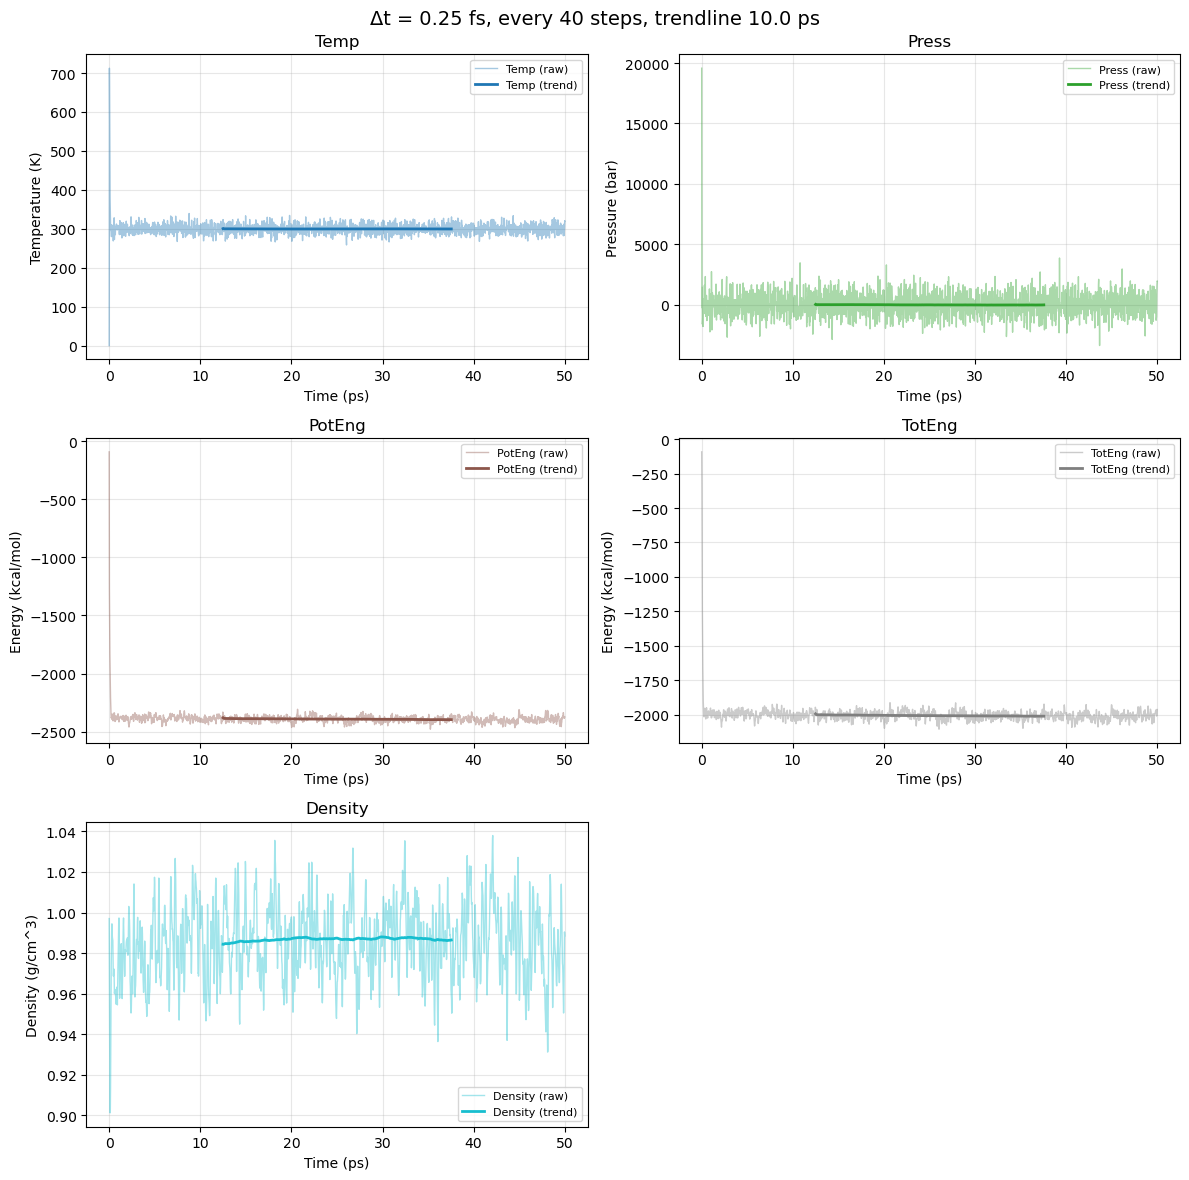

In [56]:
# LAMMPS thermo parser + physical-time plots + centered trendlines
# Assumes "thermo_modify line multi" and lines like:
# Step     =   520000 Temp = ... TotEng = ...
# PotEng   = ... KinEng = ...
# etc.

import re
import numpy as np
import matplotlib.pyplot as plt

def read_lammps_thermo_multiline(filename):
    """
    Parse LAMMPS thermo output in 'multi' line format, e.g.:
      Step     =   520000 Temp     =   992.7 ...
      PotEng   =   ...   KinEng   = ...
    Returns dict: {column_name: list of values}.
    """
    data = {}
    step_list = []
    
    with open(filename, "r") as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        # Start of a thermo record (first line with Step = ...)
        if line.startswith("Step") and "=" in line:
            block_vals = {}
            
            # Parse consecutive "name = value" lines
            while i < len(lines):
                line = lines[i].strip()
                
                # Stop block if line does not contain "=" or looks like non-thermo
                if "=" not in line:
                    break
                if line.startswith("------------ Step") and "CPU" in line:
                    break
                
                tokens = line.split()
                # tokens: Name, '=', val, Name, '=', val, ...
                j = 0
                while j < len(tokens) - 2:
                    name = tokens[j]
                    if tokens[j+1] != "=":
                        j += 1
                        continue
                    val_str = tokens[j+2]
                    try:
                        val = float(val_str)
                    except ValueError:
                        j += 3
                        continue
                    block_vals[name] = val
                    j += 3
                
                i += 1
            
            # One thermo record done
            if "Step" in block_vals:
                step_list.append(block_vals["Step"])
                for name, val in block_vals.items():
                    data.setdefault(name, []).append(val)
            continue
        
        i += 1
    
    if "Step" not in data and step_list:
        data["Step"] = step_list
    
    return data

def moving_average_centered(y, window_points):
    """
    Centered moving average.
    Returns NaN near the ends where a full window doesn't fit,
    so trendline exists only in the interior.
    """
    y = np.asarray(y, float)
    n = len(y)
    if window_points < 2 or n == 0:
        return np.full_like(y, np.nan)
    window_points = min(window_points, n)
    half = window_points // 2

    kernel = np.ones(window_points) / window_points
    conv = np.convolve(y, kernel, mode="valid")  # length n - window_points + 1

    trend = np.full(n, np.nan)
    trend[half:half+len(conv)] = conv
    return trend

# ---------- USER SETTINGS ----------
logfile = "../tmp/m5/npt.eng"   # your log/eng file
dt_fs   = 0.25             # timestep size in fs
thermo_stride = 40         # 'thermo' frequency (steps between thermo outputs)
trend_window_ps = 10.0     # trend window in ps
time_unit = "ps"           # "ps" or "fs"
# Quantities to plot (only those present will be used)
plot_quantities = [
    "Temp",
    "Press",
    "PotEng",
    "TotEng",
    "Density"
    # "Density",
    # "v_eb",
    # "v_ew",
    # "v_ep",
    # "v_eqeq",
]
# -----------------------------------

# Parse thermo
thermo = read_lammps_thermo_multiline(logfile)
print("Parsed quantities:", list(thermo.keys()))
print("Thermo records:", len(thermo.get("Step", [])))

if "Step" not in thermo or len(thermo["Step"]) == 0:
    print("No thermo data found.")
else:
    step = np.array(thermo["Step"])
    
    # Physical time for all x-axes
    if time_unit == "fs":
        time = step * dt_fs
        time_label = "Time (fs)"
    else:
        time = step * dt_fs / 1000.0
        time_label = "Time (ps)"
    
    # Convert trend window (ps) -> number of thermo records
    dt_output_fs = thermo_stride * dt_fs
    dt_output_ps = dt_output_fs / 1000.0
    window_points = max(1, int(round(trend_window_ps / dt_output_ps)))
    print(f"Trend window: {trend_window_ps} ps ≈ {window_points} thermo points")
    
    # Filter to available quantities
    plot_quantities = [q for q in plot_quantities if q in thermo]
    n_plots = len(plot_quantities)
    if n_plots == 0:
        print("None of the requested quantities are present.")
    else:
        ncols = 2
        nrows = (n_plots + 1) // 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
        if nrows == 1:
            axes = np.array(axes).reshape(1, -1)
        
        fig.suptitle(
            f"Δt = {dt_fs} fs, every {thermo_stride} steps, trendline {trend_window_ps} ps",
            fontsize=14
        )
        colors = plt.cm.tab10(np.linspace(0, 1, max(n_plots, 1)))
        
        for idx, qty in enumerate(plot_quantities):
            row, col = divmod(idx, ncols)
            ax = axes[row, col]
            
            arr = np.array(thermo[qty])
            trend = moving_average_centered(arr, window_points)
            
            # Raw data
            ax.plot(time, arr, color=colors[idx], alpha=0.4, linewidth=1, label=f"{qty} (raw)")
            # Trend (only interior; NaNs at ends)
            ax.plot(time, trend, color=colors[idx], linewidth=2, label=f"{qty} (trend)")
            
            ax.set_title(qty)
            ax.set_xlabel(time_label)
            ax.grid(True, alpha=0.3)
            
            # Y labels heuristics
            if qty == "Temp":
                ax.set_ylabel("Temperature (K)")
            elif qty in ["TotEng", "PotEng", "KinEng"]:
                ax.set_ylabel("Energy (kcal/mol)")
            elif qty.startswith("P"):
                ax.set_ylabel("Pressure (bar)")
            elif qty == "Density":
                ax.set_ylabel("Density (g/cm^3)")
            
            if len(arr) > 1:
                margin = 0.05 * (arr.max() - arr.min())
            else:
                margin = 1.0
            ax.set_ylim(arr.min() - margin, arr.max() + margin)
            ax.legend(loc="best", fontsize=8)
        
        # Hide unused subplots
        for j in range(n_plots, nrows*ncols):
            row, col = divmod(j, ncols)
            axes[row, col].set_visible(False)
        
        plt.tight_layout()
        plt.show()


## 7. Radial Distribution Function g(r)

The **radial distribution function** (RDF) describes local structure:

$$g(r) = \frac{V}{N^2} \left\langle \sum_{i \ne j} \delta(r - r_{ij}) \right\rangle \frac{1}{4\pi r^2 \Delta r}$$

For liquid water the **O–O g(r)** has characteristic peaks at:
- ~2.75 Å (first shell, ~4.5 neighbors)
- ~4.5 Å (second shell)
- ~6.8 Å (third shell)

In [87]:
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
import numpy as np

# ── Config ──────────────────────────────────────────────────────────────────
TRAJECTORY   = "../tmp/m5/nvt_analysis.lammpstrj"
R_MIN        = 0.5   # Å  — avoid the r=0 singularity
R_MAX        = 10.0  # Å
N_BINS       = 200
OUTPUT_FILE  = "rdf_data_OO.dat"
# ────────────────────────────────────────────────────────────────────────────

# Load trajectory, skip frame 0 (LAMMPS often writes a garbage/init frame)
u = mda.Universe(TRAJECTORY, format="LAMMPSDUMP")
u.trajectory[1]

group_A = u.select_atoms("type 1")
group_B = u.select_atoms("type 1")

n_B = len(group_B)
print(f"  group_A: {len(group_A)} atoms | group_B: {n_B} atoms")

# exclusion_block=(1,1) removes self-pairs when A and B are the same group
irdf = rdf.InterRDF(
    group_A,
    group_B,
    nbins=N_BINS,
    range=(R_MIN, R_MAX),
    exclusion_block=(1, 1),   # <── key fix: skip self-contributions
)
irdf.run(start=1)             # start=1 skips frame 0 at the trajectory level

# ── Extract results ──────────────────────────────────────────────────────────
r   = irdf.results.bins        # bin centres, shape (N_BINS,)
g_r = irdf.results.rdf         # g(r),        shape (N_BINS,)
dr  = r[1] - r[0]              # bin width (uniform)

# Number density from frames actually analysed (frames 1 … end)
volumes = np.array([ts.volume for ts in u.trajectory[1:]])
rho     = n_B / np.mean(volumes)   # atoms / Å³
print(f"  mean box volume : {np.mean(volumes):.3f} Å³")
print(f"  number density  : {rho:.6f} atoms/Å³")

# ── Coordination number: CN(r) = ∫₀ʳ 4π r'² g(r') ρ dr' ────────────────────
# Use the midpoint rule cleanly on the bin-centre array.
# np.cumsum sums left-to-right; each term is the shell contribution at r[i].
shell_counts = 4.0 * np.pi * r**2 * g_r * rho * dr
cn_r         = np.cumsum(shell_counts)

# ── Save ─────────────────────────────────────────────────────────────────────
data = np.column_stack((r, g_r, cn_r))
np.savetxt(
    OUTPUT_FILE,
    data,
    header="r(A)   g(r)   CN(r)",
    fmt="%.6f",
)
print(f"  Saved → {OUTPUT_FILE}")

# Quick sanity: print CN at a few radii
for target_r in [2.0, 3.0, 4.0, 5.0]:
    idx = np.argmin(np.abs(r - target_r))
    print(f"  CN({target_r:.1f} Å) = {cn_r[idx]:.3f}")

  group_A: 216 atoms | group_B: 216 atoms
  mean box volume : 6537.649 Å³
  number density  : 0.033039 atoms/Å³
  Saved → rdf_data_OO.dat
  CN(2.0 Å) = 0.000
  CN(3.0 Å) = 3.231
  CN(4.0 Å) = 7.840
  CN(5.0 Å) = 17.027


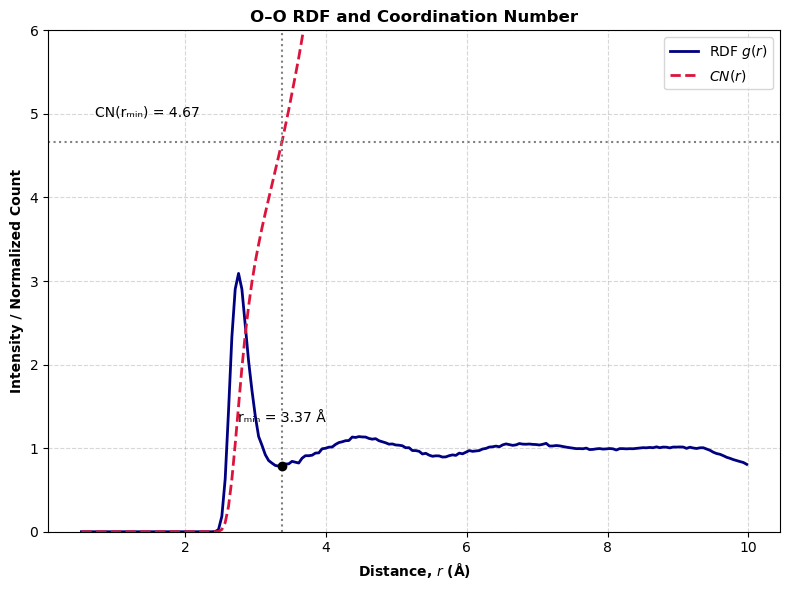

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
data = np.loadtxt("rdf_data_OO.dat")
r = data[:, 0]
g_r = data[:, 1]
cn = data[:, 2]

# ---------------------------------------------------------
# 2. Find first minimum of RDF
# ---------------------------------------------------------
# We search after the first peak: find peak index
peak_idx = np.argmax(g_r)

# Find minimum after the peak
min_idx = peak_idx + np.argmin(g_r[peak_idx:])
r_min = r[min_idx]
g_min = g_r[min_idx]
cn_at_min = cn[min_idx]

# ---------------------------------------------------------
# 3. Setup Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# RDF curve
plt.plot(r, g_r, color='navy', lw=2, label='RDF $g(r)$')

# CN curve
plt.plot(r, cn, color='crimson', lw=2, ls='--', label='$CN(r)$')

# ---------------------------------------------------------
# 4. Add dropline + horizontal CN line
# ---------------------------------------------------------
# Vertical dropline at first minimum
plt.axvline(r_min, color='gray', ls=':', lw=1.5)

# Horizontal line at CN(r_min)
plt.axhline(cn_at_min, color='gray', ls=':', lw=1.5)

# Annotate the point
plt.scatter([r_min], [g_min], color='black', zorder=5)
plt.text(r_min, g_min + 0.5,
         f"rₘᵢₙ = {r_min:.2f} Å",
         ha='center', va='bottom', fontsize=10)

plt.text(r.min() + 0.02*(r.max()-r.min()), cn_at_min + 0.3,
         f"CN(rₘᵢₙ) = {cn_at_min:.2f}",
         fontsize=10)

# ---------------------------------------------------------
# 5. Labels, limits, styling
# ---------------------------------------------------------
plt.title('O–O RDF and Coordination Number', fontweight='bold')
plt.xlabel('Distance, $r$ (Å)', fontweight='bold')
plt.ylabel('Intensity / Normalized Count', fontweight='bold')
plt.ylim(0, 6)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("rdf_OO_single_panel_with_minima.png", dpi=300)
plt.show()

## 8. Self-Diffusion Coefficient from MSD

The **Einstein relation** gives the diffusion coefficient from the mean-square displacement:

$$D = \lim_{t\to\infty} \frac{\langle |\mathbf{r}(t) - \mathbf{r}(0)|^2 \rangle}{6t}$$

For SPC/E water at 300 K, $D \approx 2.4 \times 10^{-9}$ m²/s (experiment: $2.3 \times 10^{-9}$ m²/s).

In [94]:
"""
Output: msd_data.dat   columns → time(ps)  MSD(Å²)  MSD_x  MSD_y  MSD_z
"""

import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import msd as msd_module

# ── Config ───────────────────────────────────────────────────────────────────
TRAJECTORY   = "../tmp/m5/nvt_analysis.lammpstrj"
ATOM_TYPE    = "1"           # MDAnalysis 'type' selection string
TIMESTEP_PS  = 0.001         # LAMMPS timestep in ps  (1 fs default)
DUMP_EVERY   = 1000           # frames between trajectory dumps (thermo_style)
START_FRAME  = 1             # skip frame 0 (LAMMPS init garbage)
OUTPUT_FILE  = "msd_data.dat"
# ────────────────────────────────────────────────────────────────────────────

u = mda.Universe(TRAJECTORY, format="LAMMPSDUMP")
u.trajectory[START_FRAME]

atoms = u.select_atoms(f"type {ATOM_TYPE}")
print(f"  Selected {len(atoms)} atoms of type {ATOM_TYPE}")

# ── MSD via MDAnalysis EinsteinMSD ───────────────────────────────────────────
# fft=True uses the fast FFT-based algorithm (much faster for long trajectories)
MSD = msd_module.EinsteinMSD(atoms, select="all", msd_type="xyz", fft=True)
MSD.run(start=START_FRAME)

n_frames  = MSD.n_frames
msd_total = MSD.results.timeseries          # shape (n_frames,)  units: Å²

# Per-dimension MSD (rerun with msd_type x/y/z)
msd_xyz = {}
for dim in ("x", "y", "z"):
    m = msd_module.EinsteinMSD(atoms, select="all", msd_type=dim, fft=True)
    m.run(start=START_FRAME)
    msd_xyz[dim] = m.results.timeseries

# ── Time axis ────────────────────────────────────────────────────────────────
dt_ps     = TIMESTEP_PS * DUMP_EVERY        # time between saved frames (ps)
time_ps   = np.arange(n_frames) * dt_ps    # shape (n_frames,)

# ── Linear fit in the diffusive regime (skip first 20 % of the trajectory) ──
fit_start = int(0.20 * n_frames)
fit_end   = int(0.90 * n_frames)

slope, intercept = np.polyfit(
    time_ps[fit_start:fit_end],
    msd_total[fit_start:fit_end],
    1,
)
# D = slope / (2*d)  with d=3 → Å²/ps → convert to m²/s  (* 1e-20 / 1e-12 = 1e-8)
D_ang2_ps = slope / 6.0            # Å²/ps
D_m2_s    = D_ang2_ps * 1e-8       # m²/s  (1 Å²/ps = 1e-8 m²/s)

print(f"\n  MSD linear fit  (frames {fit_start}–{fit_end})")
print(f"  slope           : {slope:.6f} Å²/ps")
print(f"  D (Å²/ps)       : {D_ang2_ps:.6f}")
print(f"  D (m²/s)        : {D_m2_s:.4e}")
print(f"  D (cm²/s)       : {D_m2_s*1e4:.4e}")

# ── Save ─────────────────────────────────────────────────────────────────────
header = (
    f"Self-diffusion coefficient D = {D_m2_s:.6e} m^2/s  "
    f"({D_ang2_ps:.6f} A^2/ps)\n"
    f"Fit range: {time_ps[fit_start]:.2f} – {time_ps[fit_end]:.2f} ps\n"
    f"Columns: time(ps)  MSD(A^2)  MSD_x(A^2)  MSD_y(A^2)  MSD_z(A^2)"
)

data = np.column_stack((
    time_ps,
    msd_total,
    msd_xyz["x"],
    msd_xyz["y"],
    msd_xyz["z"],
))
np.savetxt(OUTPUT_FILE, data, header=header, fmt="%.6f")
print(f"\n  Saved → {OUTPUT_FILE}")

  Selected 216 atoms of type 1


100%|██████████| 216/216 [00:00<00:00, 9707.48it/s]


  MSD linear fit  (frames 39–179)
  slope           : 1.368097 Å²/ps
  D (Å²/ps)       : 0.228016
  D (m²/s)        : 2.2802e-09
  D (cm²/s)       : 2.2802e-05

  Saved → msd_data.dat


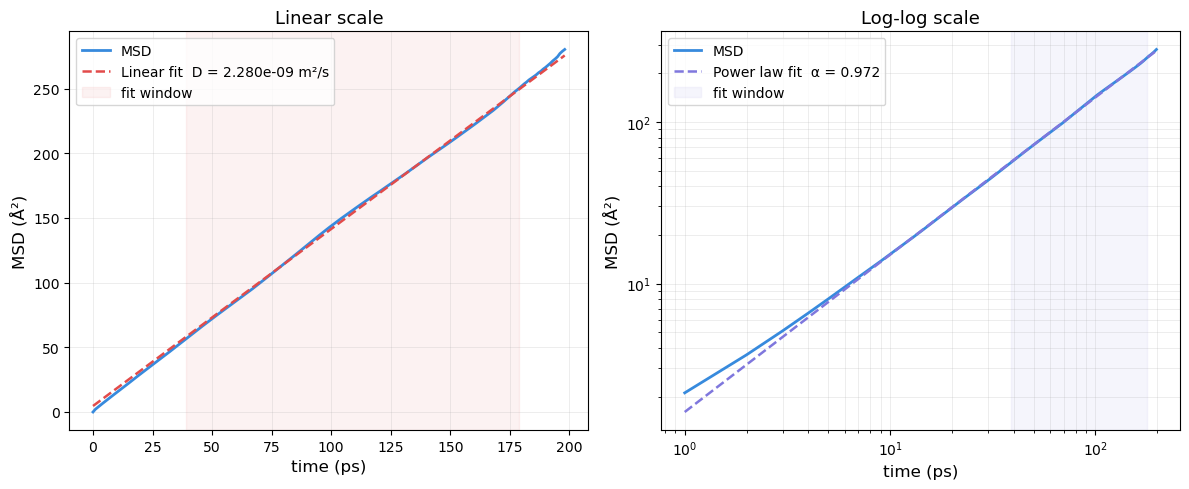

D     = 2.2802e-09 m²/s  (0.22802 Å²/ps)
alpha = 0.9723  (normal)


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── Config ────────────────────────────────────────────────────────────────────
fname  = "msd_data.dat"
fit_lo = 0.20
fit_hi = 0.90
# ─────────────────────────────────────────────────────────────────────────────

data = np.loadtxt(fname, comments="#")
time = data[:, 0]
msd  = data[:, 1]

n  = len(time)
i0 = int(fit_lo * n)
i1 = int(fit_hi * n)

# Linear fit
slope, intercept = np.polyfit(time[i0:i1], msd[i0:i1], 1)
D_ang2_ps = slope / 6.0
D_m2s     = D_ang2_ps * 1e-8

# Log-log power law fit: MSD = A * t^alpha
t_fit = time[i0:i1]
m_fit = msd[i0:i1]
t_fit = t_fit[t_fit > 0]
m_fit = m_fit[-len(t_fit):]
log_coeffs   = np.polyfit(np.log(t_fit), np.log(m_fit), 1)
alpha, log_A = log_coeffs
A            = np.exp(log_A)

t_pos = time[time > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: linear scale ───────────────────────────────────────────────────────
ax1.plot(time, msd, lw=2, color="#378ADD", label="MSD")
ax1.plot(time, slope*time + intercept, lw=1.8, ls="--", color="#E24B4A",
         label=f"Linear fit  D = {D_m2s:.3e} m²/s")
ax1.axvspan(time[i0], time[i1], color="#E24B4A", alpha=0.07, label="fit window")
ax1.set_xlabel("time (ps)", fontsize=12)
ax1.set_ylabel("MSD (Å²)", fontsize=12)
ax1.set_title("Linear scale", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, lw=0.4, alpha=0.4)

# ── Right: log-log scale ─────────────────────────────────────────────────────
ax2.plot(t_pos, msd[time > 0], lw=2, color="#378ADD", label="MSD")
ax2.plot(t_pos, A * t_pos**alpha, lw=1.8, ls="--", color="#7F77DD",
         label=f"Power law fit  α = {alpha:.3f}")
ax2.axvspan(time[i0], time[i1], color="#7F77DD", alpha=0.07, label="fit window")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("time (ps)", fontsize=12)
ax2.set_ylabel("MSD (Å²)", fontsize=12)
ax2.set_title("Log-log scale", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, which="both", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("msd_plot.png", dpi=150)
plt.show()

print(f"D     = {D_m2s:.4e} m²/s  ({D_ang2_ps:.5f} Å²/ps)")
print(f"alpha = {alpha:.4f}  ({'normal' if abs(alpha-1)<0.1 else 'subdiffusive' if alpha<1 else 'superdiffusive'})")

## 9. Long-Range Electrostatics: PPPM/Ewald

Coulomb interactions are long-ranged ($1/r$ decay). Naïve cutoff introduces large errors. The **Ewald summation** splits the interaction into:

$$U_{Coulomb} = U_{\text{real-space}} + U_{\text{reciprocal-space}} + U_{\text{self}}$$

- **Real space:** Short-ranged, screened by $\text{erfc}(\alpha r)/r$
- **Reciprocal space (k-space):** Long-range part via Fourier transform

$$U_{\text{recip}} = \frac{1}{2V\varepsilon_0} \sum_{\mathbf{k}\ne 0} \frac{e^{-k^2/4\alpha^2}}{k^2} |S(\mathbf{k})|^2$$

**PPPM** (Particle-Particle Particle-Mesh) interpolates charges onto a mesh and uses FFT → $\mathcal{O}(N \log N)$ scaling.

In LAMMPS: `kspace_style pppm 1.0e-4` (accuracy = $10^{-4}$ kcal/mol).

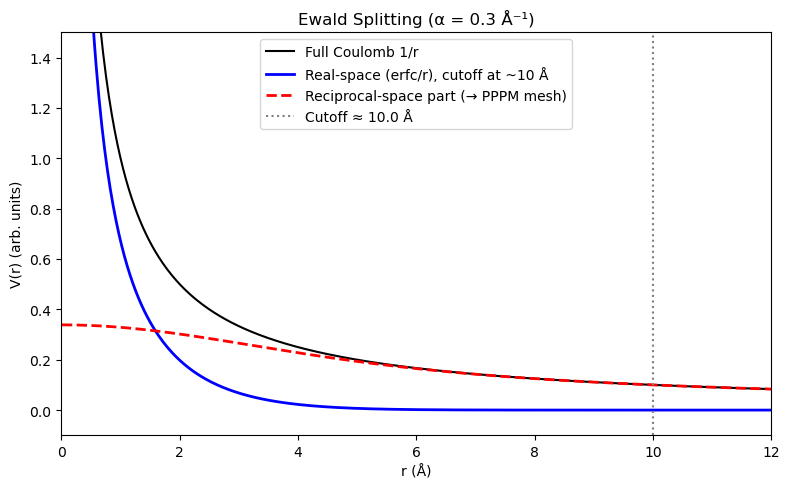

In [17]:
# Illustrate: Ewald real-space screening function vs. plain Coulomb
r_plot = np.linspace(0.01, 12, 500)
alpha = 0.3      # Ewald splitting parameter (Å⁻¹)

from scipy.special import erfc

V_coulomb  = 1.0 / r_plot                         # plain 1/r
V_real     = erfc(alpha * r_plot) / r_plot         # real-space screened
V_recip    = (1 - erfc(alpha * r_plot)) / r_plot   # reciprocal-space part (handled by k-space)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_plot, V_coulomb, 'k-',  lw=1.5, label='Full Coulomb 1/r')
ax.plot(r_plot, V_real,    'b-',  lw=2,   label='Real-space (erfc/r), cutoff at ~10 Å')
ax.plot(r_plot, V_recip,   'r--', lw=2,   label='Reciprocal-space part (→ PPPM mesh)')
ax.axvline(1/alpha * 3, ls=':', color='gray', label=f'Cutoff ≈ {1/alpha*3:.1f} Å')
ax.set_xlim(0, 12); ax.set_ylim(-0.1, 1.5)
ax.set_xlabel('r (Å)')
ax.set_ylabel('V(r) (arb. units)')
ax.set_title(f'Ewald Splitting (α = {alpha} Å⁻¹)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary and Workflow

### Complete LAMMPS Water Simulation Workflow

```
1. Build water box (Python/NumPy or Packmol)
       ↓
2. Write LAMMPS data file  (water.data)
       ↓
3. Energy minimization     (lmp -in in.minimize)
       ↓
4. NPT equilibration       (lmp -in in.nvt,  ~200 ps)
       ↓
5. NVT production run      (lmp -in in.npt,  ~1 ns)
       ↓
6. Analysis:
   - Parse thermo output   → T, P, ρ convergence
   - Compute O-O g(r)      → structure, coordination number
   - Compute O MSD         → self-diffusion D
   - Compute VACF          → vibrational density of states
```

### Key Results for SPC/E Water at 300 K, 1 atm

| Property | SPC/E | Experiment |
|----------|-------|------------|
| Density (g/cm³) | 0.997 | 0.997 |
| 1st O-O peak (Å) | 2.75 | 2.80 |
| Coordination number | ~4.5 | ~4.5 |
| D (10⁻⁹ m²/s) | 2.4 | 2.3 |
| ΔH_vap (kJ/mol) | 44.0 | 44.0 |

### References

1. Berendsen, H. J. C. *et al.* J. Phys. Chem. **1987**, 91, 6269 (SPC/E model)
2. LAMMPS Documentation: https://docs.lammps.org
3. Vega, C. & Abascal, J. L. F. Phys. Chem. Chem. Phys. **2011**, 13, 19663 (water models review)